In [ ]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HUGGING_FACE')
login(hf_token)

### Downloading the data

In [2]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="UkrainianCatholicUniversity/rukopys",
    repo_type="dataset",
    local_dir="handwritten_data"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10741 files:   0%|          | 0/10741 [00:00<?, ?it/s]

'/content/handwritten_data'

### Installing dependencies

In [3]:
%pip install yolov10
%pip install -q doclayout-yolo opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.5/953.5 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.9/373.9 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.3/711.3 kB 19.0 MB/s eta 0:00:00


In [4]:
import json
import random
from pathlib import Path
from huggingface_hub import hf_hub_download
from doclayout_yolo import YOLOv10
import os

### Check the performance of pretrained model

In [ ]:
dataset_path = Path("handwritten_data/train")
metadata_path = dataset_path / "metadata.jsonl"

FRACTION = 0.005
sampled_records = []

with open(metadata_path, 'r', encoding='utf-8') as f:
    all_lines = f.readlines()

sampled_lines = random.sample(all_lines, max(1, int(len(all_lines) * FRACTION)))
for line in sampled_lines:
    sampled_records.append(json.loads(line))

print(f"Evaluating on {len(sampled_records)} sampled images...")

repo_id = "juliozhao/DocLayout-YOLO-DocStructBench"
filename = "doclayout_yolo_docstructbench_imgsz1024.pt"
model_path = hf_hub_download(repo_id=repo_id, filename=filename)
model = YOLOv10(model_path)
imgsz = 1024

In [ ]:
def compute_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0

In [ ]:
IOU_THRESHOLD = 0.50
total_tp, total_fp, total_fn = 0, 0, 0

for record in sampled_records:
    gt_boxes = []
    if record.get('regions'):
        for region in record['regions']:
            gt_boxes.append(region['bbox'])

    img_file = dataset_path / record['file_name']

    results = model.predict(source=str(img_file), imgsz=imgsz, conf=0.25, verbose=False)

    pred_boxes = []
    for result in results:
        for box in result.boxes.xyxy:
            pred_boxes.append(box.cpu().numpy().tolist())

    matched_gt = set()
    tp, fp = 0, 0

    for p_box in pred_boxes:
        best_iou = 0
        best_gt_idx = -1

        for i, g_box in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            iou = compute_iou(p_box, g_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i

        if best_iou >= IOU_THRESHOLD:
            matched_gt.add(best_gt_idx)
            tp += 1
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)

    total_tp += tp
    total_fp += fp
    total_fn += fn

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"Bounding Box Metrics (IoU > {IOU_THRESHOLD})")
print(f"Total True Positives:  {total_tp}")
print(f"Total False Positives: {total_fp}")
print(f"Total False Negatives: {total_fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

### Train the model on gold

In [5]:
import doclayout_yolo.engine.trainer as trainer
trainer.check_amp = lambda model: True

In [ ]:
def convert_to_yolo_format(jsonl_path, images_dir, labels_dir):
    os.makedirs(labels_dir, exist_ok=True)

    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)

            if not record.get('regions'):
                continue

            img_width = record['image_width']
            img_height = record['image_height']

            base_name = Path(record['file_name']).stem
            label_file_path = Path(labels_dir) / f"{base_name}.txt"

            with open(label_file_path, 'w') as label_file:
                for region in record['regions']:
                    x1, y1, x2, y2 = region['bbox']

                    x_center = ((x1 + x2) / 2.0) / img_width
                    y_center = ((y1 + y2) / 2.0) / img_height
                    box_width = (x2 - x1) / img_width
                    box_height = (y2 - y1) / img_height

                    class_id = 0

                    label_file.write(f"{class_id} {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}\n")

convert_to_yolo_format(
    "handwritten_data/train/metadata.jsonl",
    "handwritten_data/train/images",
    "handwritten_data/train/labels"
)

In [ ]:
import glob

label_dir = "handwritten_data/train/labels"
image_dir = "handwritten_data/train/images"

all_labels = glob.glob(f"{label_dir}/*.txt")
image_paths = []

for lbl in all_labels:
    base_name = os.path.splitext(os.path.basename(lbl))[0]
    img_path = os.path.join(image_dir, f"{base_name}.jpg")

    if os.path.exists(img_path):
        image_paths.append(os.path.abspath(img_path))

print(f"Total matched labeled images: {len(image_paths)}")

if len(image_paths) == 0:
    raise FileNotFoundError("No images found")

random.seed(42)
random.shuffle(image_paths)

split_idx = int(len(image_paths) * 0.8)
train_files = image_paths[:split_idx]
val_files = image_paths[split_idx:]

with open("train.txt", "w") as f:
    f.write("\n".join(train_files))

with open("val.txt", "w") as f:
    f.write("\n".join(val_files))

print(f"Split created: {len(train_files)} train images, {len(val_files)} validation images.")

yaml_content = f"""
train: {os.path.abspath('train.txt')}
val: {os.path.abspath('val.txt')}

nc: 1
names:
  0: region
"""

with open("dataset.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_content.strip())

print("dataset.yaml ready.")

os.environ["WANDB_MODE"] = "disabled"

model_path = "handwritten_run/fine_tune_v1/weights/best.pt"
model = YOLOv10(model_path)

results = model.train(
    data=os.path.abspath("dataset.yaml"),
    epochs=50,
    imgsz=1024,
    batch=-1,
    device="cuda:0",
    freeze=10,
    amp=True,
    cache="ram",
    workers=8,
    optimizer="AdamW",
    lr0=0.0005,
    cos_lr=True,
    patience=15,
    close_mosaic=10,
    fliplr=0.0,
    flipud=0.0,
    project="handwritten_run",
    name="fine_tune_v1",
    save=True,
)

print(f"Training complete. Best weights saved to: {results.save_dir}/weights/best.pt")

Total matched labeled images: 1330
Split created: 1064 train images, 266 validation images.
dataset.yaml ready.
Ultralytics YOLOv0.0.4 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=handwritten_run/fine_tune_v1/weights/best.pt, data=/content/dataset.yaml, epochs=50, time=None, patience=15, batch=-1, imgsz=1024, save=True, save_period=10, val_period=1, cache=ram, device=cuda:0, workers=8, project=handwritten_run, name=fine_tune_v1, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=10, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fal

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


Freezing layer 'model.0.conv.weight'
Freezing layer 'model.0.bn.weight'
Freezing layer 'model.0.bn.bias'
Freezing layer 'model.1.conv.weight'
Freezing layer 'model.1.bn.weight'
Freezing layer 'model.1.bn.bias'
Freezing layer 'model.2.cv1.conv.weight'
Freezing layer 'model.2.cv1.bn.weight'
Freezing layer 'model.2.cv1.bn.bias'
Freezing layer 'model.2.cv2.conv.weight'
Freezing layer 'model.2.cv2.bn.weight'
Freezing layer 'model.2.cv2.bn.bias'
Freezing layer 'model.2.m.0.cv1.conv.weight'
Freezing layer 'model.2.m.0.cv1.bn.weight'
Freezing layer 'model.2.m.0.cv1.bn.bias'
Freezing layer 'model.2.m.0.cv2.conv.weight'
Freezing layer 'model.2.m.0.cv2.bn.weight'
Freezing layer 'model.2.m.0.cv2.bn.bias'
Freezing layer 'model.2.m.1.cv1.conv.weight'
Freezing layer 'model.2.m.1.cv1.bn.weight'
Freezing layer 'model.2.m.1.cv1.bn.bias'
Freezing layer 'model.2.m.1.cv2.conv.weight'
Freezing layer 'model.2.m.1.cv2.bn.weight'
Freezing layer 'model.2.m.1.cv2.bn.bias'
Freezing layer 'model.3.conv.weight'
Fre

/usr/local/lib/python3.13/dist-packages/doclayout_yolo/engine/trainer.py:277: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
/usr/local/lib/python3.13/dist-packages/doclayout_yolo/utils/autobatch.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):


AutoBatch: Computing optimal batch size for imgsz=1024
AutoBatch: CUDA:0 (Tesla T4) 14.56G total, 0.16G reserved, 0.15G allocated, 14.25G free
      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output
    19510446       169.2         4.066         132.6           nan      (1, 3, 1024, 1024)                    list
    19510446       338.4         8.005         123.9           nan      (2, 3, 1024, 1024)                    list
CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 3.81 MiB is free. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 13.97 GiB is allocated by PyTorch, and 441.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/n

...

      49/50      1.73G       1.13     0.5103          0      1.167     0.4256          0         54       1024: 100%|██████████| 532/532 [02:47<00:00,  3.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 67/67 [00:35<00:00,  1.89it/s]


266
                   all        266       5059      0.897      0.882      0.926      0.587

      Epoch    GPU_mem     box_om     cls_om     dfl_om     box_oo     cls_oo     dfl_oo  Instances       Size


      50/50      1.72G      1.129     0.5057          0      1.171     0.4201          0         26       1024: 100%|██████████| 532/532 [02:48<00:00,  3.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 67/67 [00:35<00:00,  1.90it/s]


266
                   all        266       5059      0.895      0.885      0.926      0.587

50 epochs completed in 2.945 hours.


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL doclayout_yolo.nn.tasks.YOLOv10DetectionModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([doclayout_yolo.nn.tasks.YOLOv10DetectionModel])` or the `torch.serialization.safe_globals([doclayout_yolo.nn.tasks.YOLOv10DetectionModel])` context manager to allowlist this global if you trust this class/function.


In [ ]:
model = YOLOv10("handwritten_run/fine_tune_v1/weights/best.pt")
m = model.val(data=os.path.abspath("dataset.yaml"), imgsz=1024, batch=4)
print(m.box.map50, m.box.map)

Ultralytics YOLOv0.0.4 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)


val: Scanning /content/handwritten_data/train/labels.cache... 266 images, 0 backgrounds, 0 corrupt: 100%|██████████| 266/266 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/handwritten_data/train/images/22fb180b-82dc-5152-8e7b-eed13e100788.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/handwritten_data/train/images/35f4140a-b8e7-47a4-97c0-60fbad0d61e4.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/handwritten_data/train/images/c0c23483-5307-5e95-aa4f-d33a18d390c4.jpg: corrupt JPEG restored and saved



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 67/67 [00:39<00:00,  1.71it/s]


266
                   all        266       5059      0.898      0.889      0.928      0.589
Speed: 0.8ms preprocess, 122.2ms inference, 0.7ms postprocess per image
Results saved to runs/detect/val
0.9282419962588532 0.5892622247093073


In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

Validation images: 266
  downscaled 50/266
  downscaled 100/266
  downscaled 150/266
  downscaled 200/266
  downscaled 250/266
Downscaled images larger than 1024px: 0
Ground-truth regions: 5060

IoU threshold for a correct box: 0.5
 conf       P       R      F1     TP     FP     FN
 0.05   0.684   0.947   0.795   4794   2210    266
 0.10   0.749   0.937   0.833   4742   1585    318
 0.15   0.789   0.930   0.854   4706   1261    354
 0.20   0.822   0.920   0.868   4655   1010    405
 0.25   0.846   0.911   0.877   4609    840    451
 0.30   0.870   0.901   0.885   4558    679    502
 0.35   0.890   0.888   0.889   4493    553    567
 0.40   0.904   0.870   0.887   4400    466    660
 0.45   0.919   0.847   0.882   4288    380    772
 0.50   0.932   0.828   0.877   4190    305    870
 0.55   0.944   0.802   0.868   4060    240   1000
 0.60   0.951   0.762   0.846   3858    199   1202
 0.65   0.959   0.721   0.823   3650    158   1410
 0.70   0.963   0.672   0.792   3401    131   1659
 0.

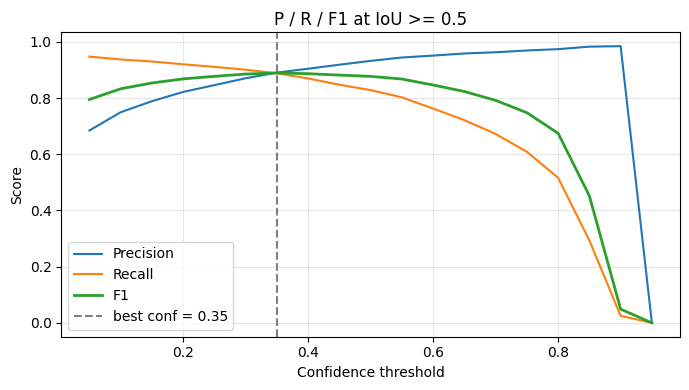

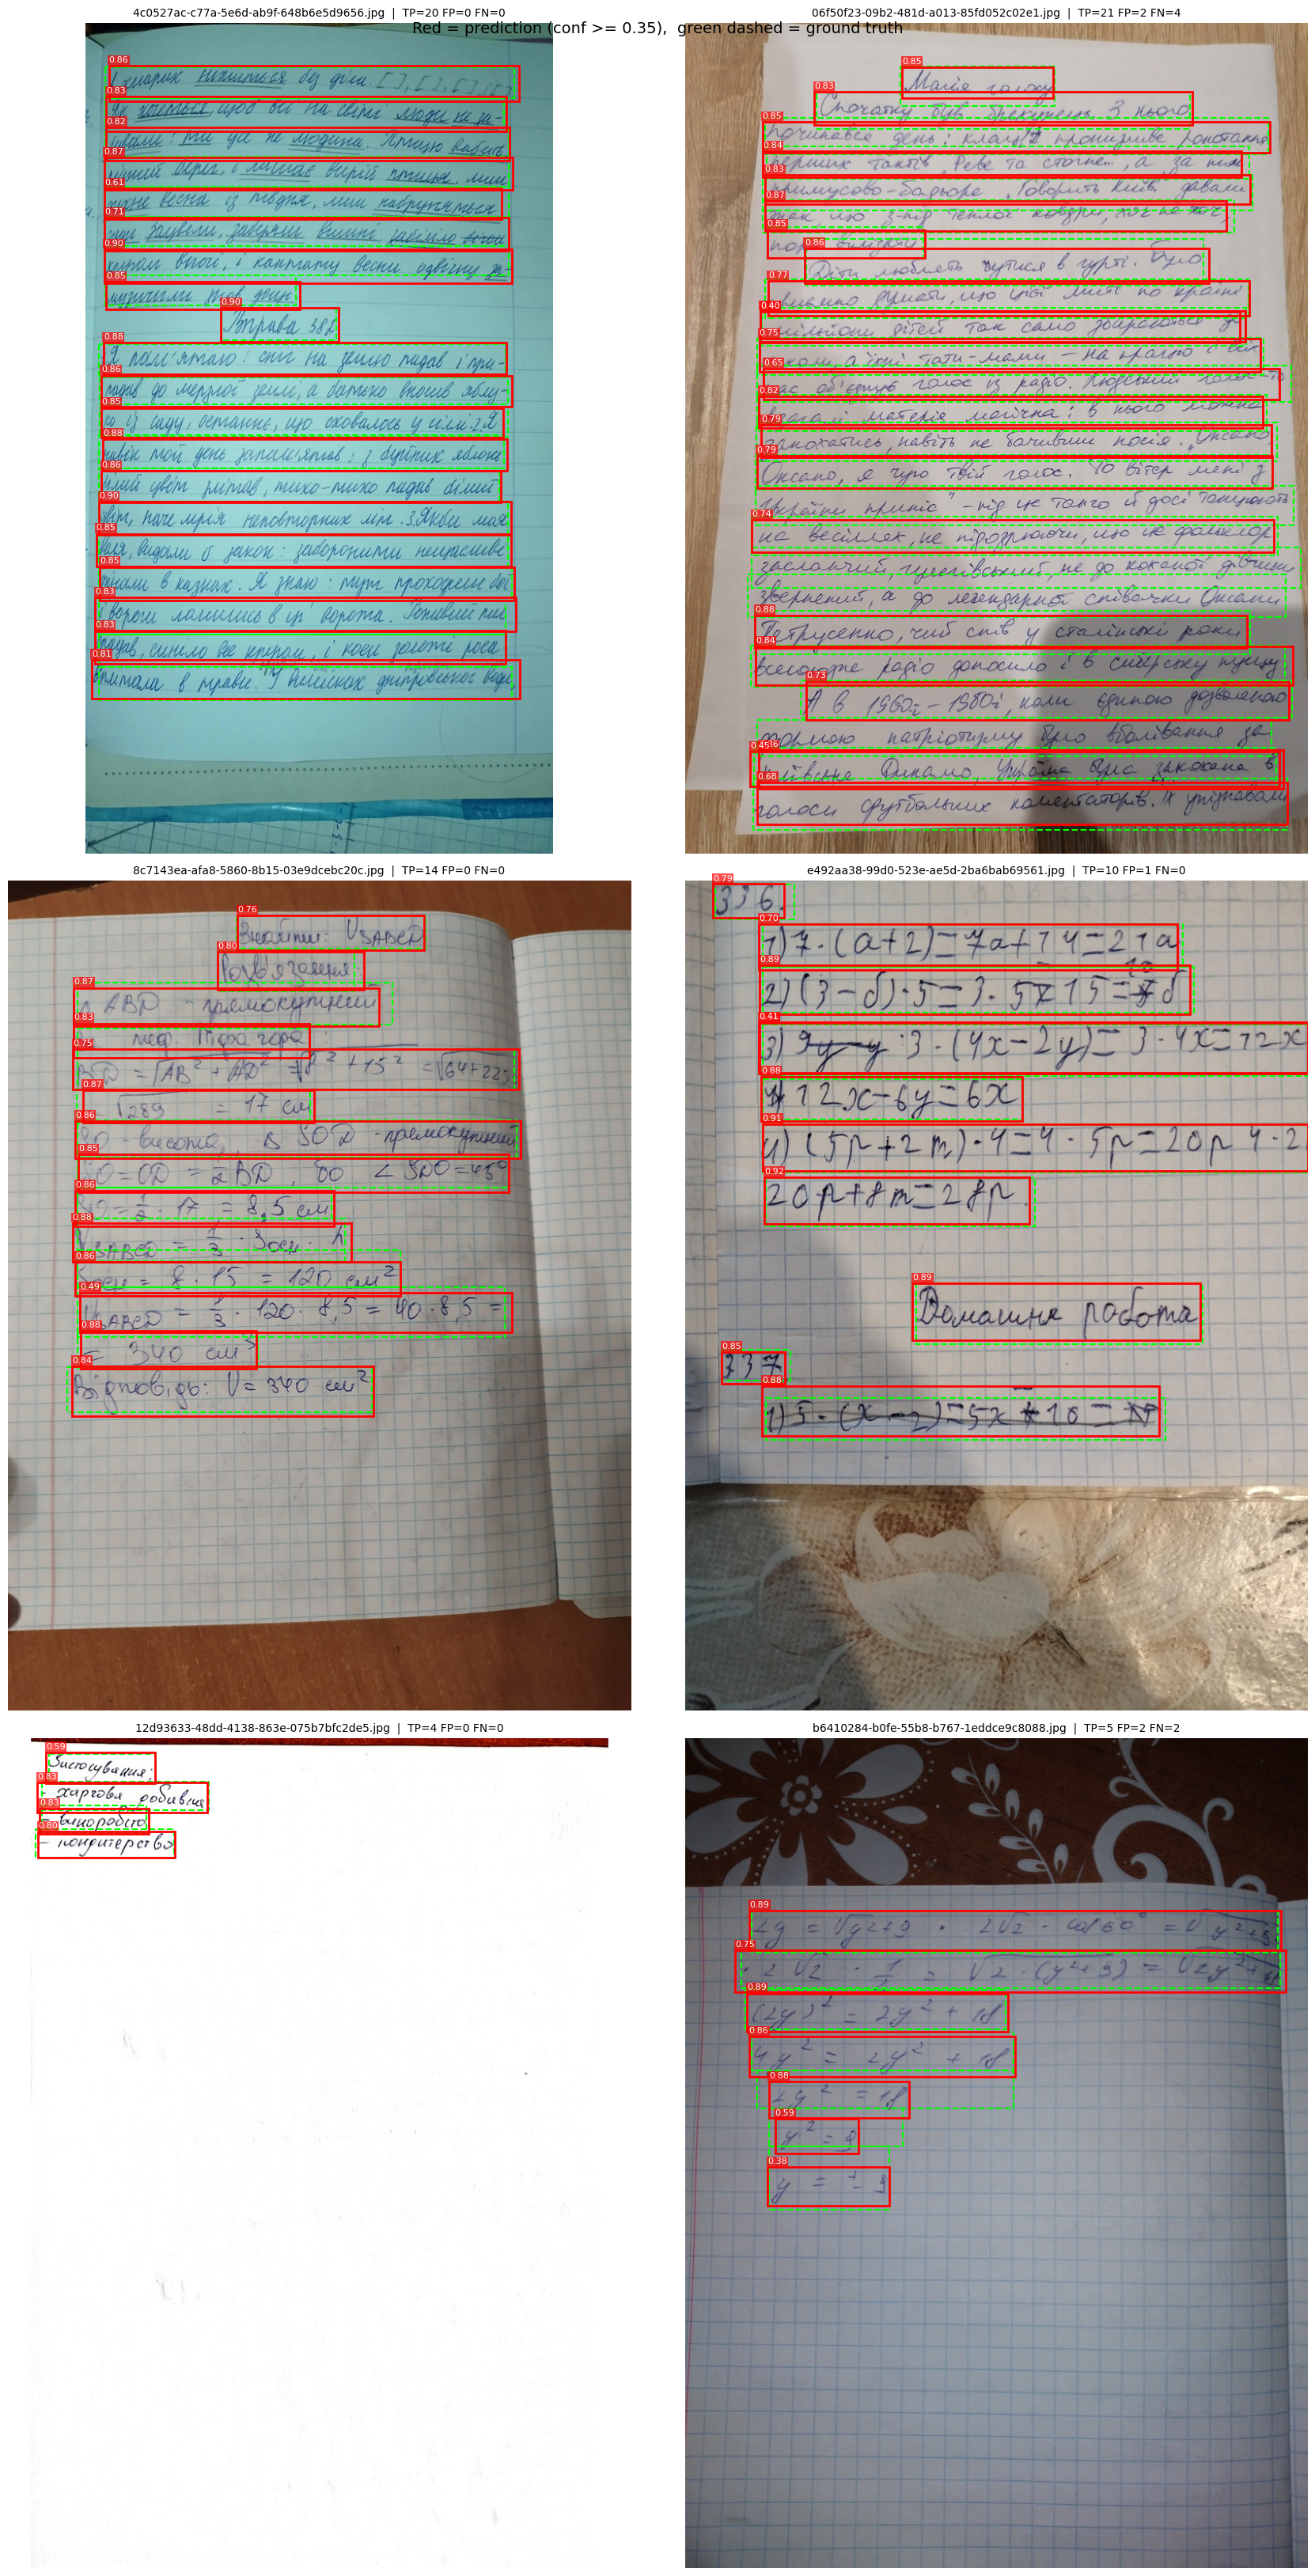

In [ ]:
WEIGHTS = "handwritten_run/fine_tune_v1/weights/best.pt"
VAL_LIST = "val.txt"
IMGSZ = 1024
IOU_THR = 0.5
VIS_CONF = None
N_VIS = 6
SEED = 0
DEVICE = "cuda:0"
SMALL_DIR = "val_small"
LONG_SIDE = 1024


Image.MAX_IMAGE_PIXELS = None


def shrink(src, dst, long_side):
    if os.path.exists(dst):
        return
    with Image.open(src) as im:
        im.draft("RGB", (long_side * 2, long_side * 2))
        im = im.convert("RGB")
        scale = long_side / max(im.size)
        if scale < 1:
            im = im.resize((round(im.width * scale), round(im.height * scale)), Image.LANCZOS)
        im.save(dst, quality=95)


def label_path_for(img_path):
    d, f = os.path.split(img_path)
    base = os.path.splitext(f)[0]
    return os.path.join(os.path.dirname(d), "labels", base + ".txt")


def load_gt(img_path, w, h):
    lp = label_path_for(img_path)
    boxes = []
    if os.path.exists(lp):
        with open(lp) as f:
            for line in f:
                p = line.split()
                if len(p) < 5:
                    continue
                vals = list(map(float, p[1:]))
                if len(vals) == 4:
                    cx, cy, bw, bh = vals
                    x1, y1 = (cx - bw / 2) * w, (cy - bh / 2) * h
                    x2, y2 = (cx + bw / 2) * w, (cy + bh / 2) * h
                else:
                    xs, ys = np.array(vals[0::2]) * w, np.array(vals[1::2]) * h
                    x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
                boxes.append([x1, y1, x2, y2])
    return np.array(boxes, dtype=np.float32).reshape(-1, 4)


def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=np.float32)
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0])
    iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2])
    iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)


def match_counts(pred, scores, gt, iou_thr):
    if len(pred) == 0:
        return 0, 0, len(gt)
    if len(gt) == 0:
        return 0, len(pred), 0
    order = np.argsort(-scores)
    pred = pred[order]
    ious = iou_matrix(pred, gt)
    used = np.zeros(len(gt), dtype=bool)
    tp = 0
    for i in range(len(pred)):
        cand = np.where(~used, ious[i], -1)
        j = cand.argmax()
        if cand[j] >= iou_thr:
            used[j] = True
            tp += 1
    fp = len(pred) - tp
    fn = len(gt) - tp
    return tp, fp, fn


with open(VAL_LIST) as f:
    val_paths = [l.strip() for l in f if l.strip()]
print(f"Validation images: {len(val_paths)}")

os.makedirs(SMALL_DIR, exist_ok=True)
small_paths = []
for i, p in enumerate(val_paths):
    dst = os.path.join(SMALL_DIR, os.path.basename(p))
    shrink(p, dst, LONG_SIDE)
    small_paths.append(dst)
    if (i + 1) % 50 == 0:
        print(f"  downscaled {i + 1}/{len(val_paths)}")


too_big = []
for p in small_paths:
    with Image.open(p) as im:
        if max(im.size) > LONG_SIDE + 2:
            too_big.append((p, im.size))
print(f"Downscaled images larger than {LONG_SIDE}px: {len(too_big)}")
for p, s in too_big[:10]:
    print("  ", p, s)
if too_big:
    raise RuntimeError("Some downscaled images are still large. Delete the val_small folder and re-run.")

records = []
for path, small in zip(val_paths, small_paths):
    try:
        r = model.predict(
            source=small,
            imgsz=IMGSZ,
            conf=0.001,
            device=DEVICE,
            batch=1,
            verbose=False,
        )[0]
    except torch.cuda.OutOfMemoryError:
        with Image.open(small) as im:
            print("CUDA OOM on:", small, "size:", im.size)
        raise
    h, w = r.orig_shape
    records.append({
        "path": path,
        "small": small,
        "gt": load_gt(path, w, h),
        "pred": r.boxes.xyxy.cpu().numpy(),
        "score": r.boxes.conf.cpu().numpy(),
    })

total_gt = sum(len(r["gt"]) for r in records)
print(f"Ground-truth regions: {total_gt}")

def evaluate_at(conf):
    TP = FP = FN = 0
    for r in records:
        keep = r["score"] >= conf
        tp, fp, fn = match_counts(r["pred"][keep], r["score"][keep], r["gt"], IOU_THR)
        TP += tp; FP += fp; FN += fn
    P = TP / (TP + FP + 1e-9)
    R = TP / (TP + FN + 1e-9)
    F1 = 2 * P * R / (P + R + 1e-9)
    return P, R, F1, TP, FP, FN


thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
results = [(t, *evaluate_at(t)) for t in thresholds]

print(f"\nIoU threshold for a correct box: {IOU_THR}")
print(f"{'conf':>5} {'P':>7} {'R':>7} {'F1':>7} {'TP':>6} {'FP':>6} {'FN':>6}")
for t, P, R, F1, TP, FP, FN in results:
    print(f"{t:5.2f} {P:7.3f} {R:7.3f} {F1:7.3f} {TP:6d} {FP:6d} {FN:6d}")

best = max(results, key=lambda x: x[3])
print(f"\nBest F1 = {best[3]:.3f} at conf = {best[0]:.2f} "
      f"(P = {best[1]:.3f}, R = {best[2]:.3f})")

plt.figure(figsize=(7, 4))
plt.plot(thresholds, [x[1] for x in results], label="Precision")
plt.plot(thresholds, [x[2] for x in results], label="Recall")
plt.plot(thresholds, [x[3] for x in results], label="F1", linewidth=2)
plt.axvline(best[0], color="gray", linestyle="--", label=f"best conf = {best[0]:.2f}")
plt.xlabel("Confidence threshold")
plt.ylabel("Score")
plt.title(f"P / R / F1 at IoU >= {IOU_THR}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("f1_vs_conf.png", dpi=150)
plt.show()

vis_conf = VIS_CONF if VIS_CONF is not None else best[0]
random.seed(SEED)
sample = random.sample(records, min(N_VIS, len(records)))

cols = 2
rows = int(np.ceil(len(sample) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(9 * cols, 11 * rows))
axes = np.array(axes).reshape(-1)

for ax, r in zip(axes, sample):
    img = Image.open(r["small"]).convert("RGB")
    ax.imshow(img)

    for x1, y1, x2, y2 in r["gt"]:
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor="lime", linewidth=1.5, linestyle="--"))

    keep = r["score"] >= vis_conf
    for (x1, y1, x2, y2), s in zip(r["pred"][keep], r["score"][keep]):
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor="red", linewidth=2))
        ax.text(x1, max(y1 - 4, 0), f"{s:.2f}", color="white", fontsize=8,
                bbox=dict(facecolor="red", alpha=0.7, pad=1, edgecolor="none"))

    tp, fp, fn = match_counts(r["pred"][keep], r["score"][keep], r["gt"], IOU_THR)
    ax.set_title(f"{os.path.basename(r['path'])}  |  TP={tp} FP={fp} FN={fn}", fontsize=10)
    ax.axis("off")

for ax in axes[len(sample):]:
    ax.axis("off")

fig.suptitle(f"Red = prediction (conf >= {vis_conf:.2f}),  green dashed = ground truth", fontsize=14)
plt.tight_layout()
plt.savefig("val_predictions.png", dpi=120)
plt.show()